In [1]:
import numpy as np
from os import listdir

from AutoencoderAPI.utils.decibel import file_name_table
from AutoencoderAPI.utils.correlation import second_order
from AutoencoderAPI.autoencoderKernelDensity import autoencoder_kernelDensity

In [2]:
decibel_dict= file_name_table('Datasets/NIST (250) train/', 250, (67,71))

In [3]:
signal_size = 250
path_test = 'Datasets/NIST (250) test/'
path_train = 'Datasets/NIST (250) train/'

X_test = np.concatenate([np.fromfile(f"{path_test}{fileName}",dtype=np.float16).reshape(-1,signal_size) for fileName in listdir(path_test)])
X_test = X_test.astype("double")

X_train = np.concatenate([np.fromfile(f"{path_train}{fileName}",dtype=np.float16).reshape(-1,signal_size) for fileName in listdir(path_train)])
X_train = X_train.astype("double")

X = np.concatenate((X_test,X_train))

Bandwidth : 0.01


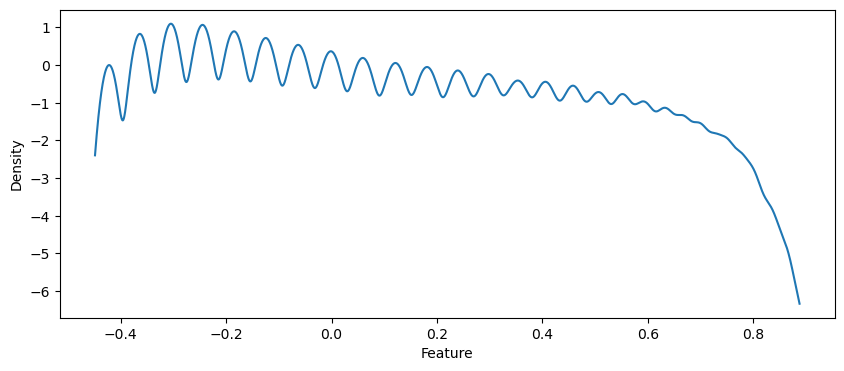

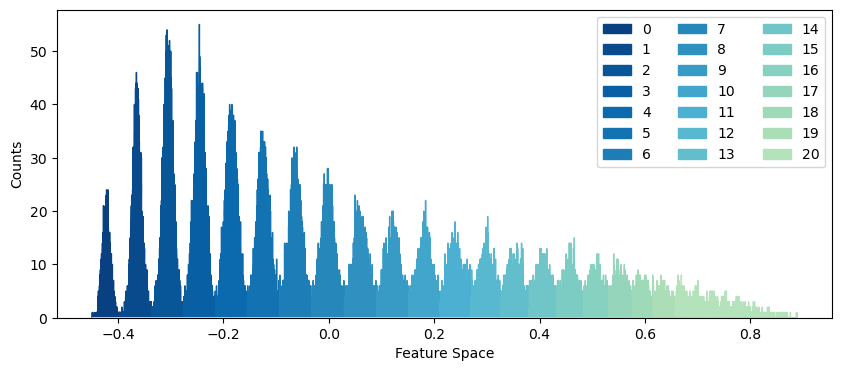

In [4]:
ak = autoencoder_kernelDensity("Autoencoder Log/sweep NIST 2/run 07/fold 0")
ak.fit(X[::2], plot_cluster=True, plot_traces=False, plot_density=True, bw_cst=[0.01], flip=False)

In [5]:
decibel = []
g2 = []
average = []
for key in decibel_dict.keys():
    X = decibel_dict[key]
    labels = ak.get_label(X)
    decibel.append(float(key))
    g2.append(second_order(labels))
    average.append(np.mean(labels))

In [6]:
decibel

[26.0, 26.5, 27.0, 27.5, 28.0, 28.5, 29.0]

In [7]:
g2

[0.9829239536382878,
 0.9981236121176714,
 1.0020659035223178,
 1.0012541442242116,
 0.9975336884728073,
 1.0096311777244207,
 1.010700443843311]

In [8]:
average

[15.475,
 11.2595703125,
 7.93232421875,
 5.6955078125,
 3.999609375,
 2.87763671875,
 2.01044921875]

In [9]:
def function(dB, n_0, cst):
    dB = np.array(dB)
    return n_0 * 10**(-dB * cst)

def function1(dB, n_0, cst):
    dB = np.array(dB)
    return n_0 * np.exp(-dB - cst)

[6.10545874e+08 2.92068700e-01]


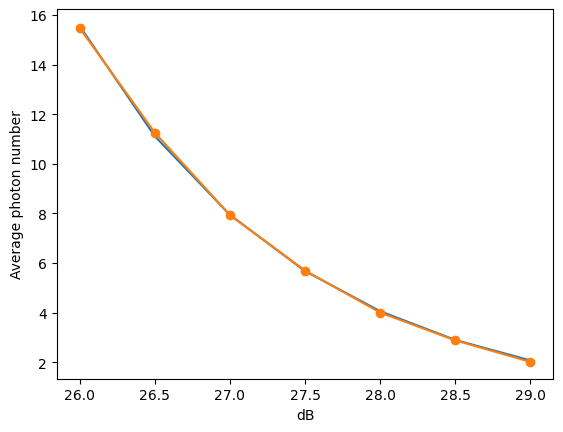

In [10]:
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

popt, pcov = curve_fit(function, decibel, average, 
                       bounds=([0, 0], [1e9, 40]),
                       p0=[4,0.1])
plt.plot(decibel, function(decibel, *popt))
plt.plot(decibel, average,marker='o' )
#plt.yscale("log")
plt.xlabel("dB")
plt.ylabel("Average photon number")
print(popt)